In [111]:
# step one - data loader setup from the dataset
# step two - VAE training
# step three - save VAE
import einops
import jax.numpy as jnp
import optax
from flax import nnx
from jaxtyping import Array, Shaped

from wm.data import make_observation_loader
from wm.vae import VAE

In [ ]:
batch_size = 128

loader = make_observation_loader(
    "../data",
    batch_size=batch_size,
    shuffle=True,
    seed=0,
    num_epochs=1,
    worker_count=2,
)

n_examples = len(loader._data_source)
print(f"Loaded {n_examples:,} examples in loader.")

Loaded 10,100,000 examples in loader.


In [16]:
for x in loader:
    break

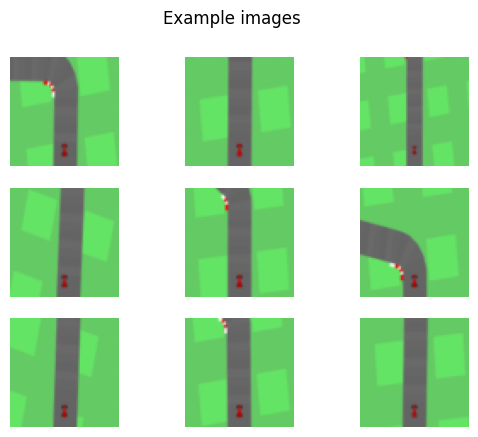

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3)
for i in range(9):
    ax = axes[i % 3, i // 3]
    ax.imshow(x[i])
    ax.axis("off")

fig.suptitle("Example images")
plt.show()

In [18]:
def save_reconstruction(x: Array, x_pred: Array, fp: str):
    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(x)
    axes[0].axis("off")
    axes[0].set_title("Real")
    axes[1].imshow(x_pred)
    axes[1].axis("off")
    axes[1].set_title("Reconstructed")
    plt.savefig(fp)
    plt.close()

In [19]:
@nnx.value_and_grad(has_aux=True)
def loss_fn(model: VAE, x: Shaped[Array, "B H W C"]) -> Shaped[Array, ""]:
    mu, logvar, z = model.encode(x).values()
    x_pred = model.decode(z)

    decoder_sigma = model.sigma

    D = 64 * 64 * 3  # number of pixels/channels
    err = x - x_pred
    mse = einops.einsum(err, err, "B h w c, B h w c -> B")
    recon_loss = (
        mse / (2 * decoder_sigma**2)
        + D * jnp.log(decoder_sigma)
        + D / 2 * jnp.log(2 * jnp.pi)
    )
    recon_loss = jnp.mean(recon_loss)
    kl_loss = -0.5 * jnp.sum(1 + logvar - mu**2 - jnp.exp(logvar), axis=-1)
    kl_loss = jnp.mean(kl_loss)

    loss = recon_loss + kl_loss
    return loss, {"loss": loss, "kl": kl_loss, "recon": recon_loss}


@nnx.jit
def train_step(model, optim, batch):
    (_, loss), grads = loss_fn(model, batch)
    optim.update(model, grads)
    return loss, grads


model = VAE(latent_dim=32, rngs=nnx.Rngs(0))
# lr_schedule = ...
tx = optax.adam(learning_rate=8e-4)
optim = nnx.Optimizer(model, tx, wrt=nnx.Param)

# for batch in loader:
loss, grads = train_step(model, optim, x)  # call it once to jit

In [22]:
from tqdm import tqdm

losses = []

pbar = tqdm(total=n_examples // batch_size)
for x in loader:
    loss, grads = train_step(model, optim, x)
    losses.append(loss)

    pbar.update(1)

pbar.close()

100%|██████████| 3906/3906 [19:44<00:00,  3.30it/s] 


In [ ]:
# from tqdm import tqdm

# # training on
# x = batch
# losses = []
# for i in tqdm(range(5000)):
#     loss, grads = train_step(model, optim, batch)
#     losses.append(loss)
#     if i % 10 == 0:
#         save_reconstruction(x[0], model(x[0]), f"imgs/reconstructions/{i // 10:03}.png")

100%|██████████| 5000/5000 [29:29<00:00,  2.83it/s]


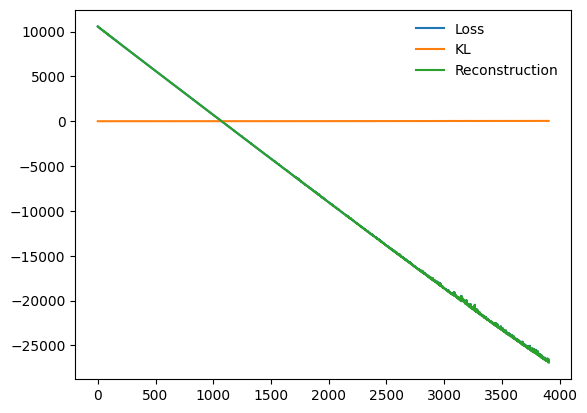

In [23]:
import matplotlib.pyplot as plt

plt.plot([d["loss"] for d in losses], label="Loss")
plt.plot([d["kl"] for d in losses], label="KL")
plt.plot([d["recon"] for d in losses], label="Reconstruction")

plt.legend(frameon=False)

In [29]:
# {'kl': Array(6.348282, dtype=float32),
#  'loss': Array(3923.0557, dtype=float32),
#  'recon': Array(3916.7073, dtype=float32)}
losses[-1]

{'kl': Array(26.564934, dtype=float32),
 'loss': Array(-36745.375, dtype=float32),
 'recon': Array(-36771.94, dtype=float32)}

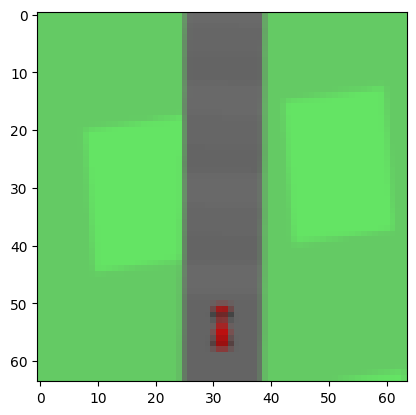

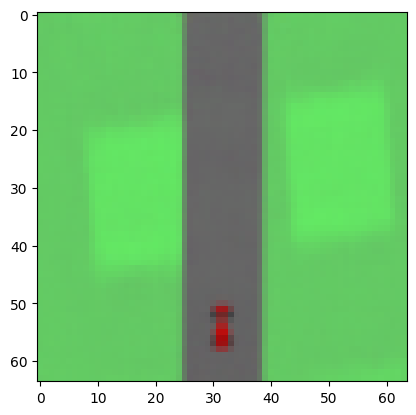

In [33]:
x_pred = model(x)
plt.imshow(x[50])
plt.show()
plt.imshow(x_pred[50])

In [31]:
import glob

import mediapy as media
import numpy as np
from PIL import Image

paths = glob.glob("./imgs/reconstructions/*.png")
paths = sorted(paths)
images = [np.array(Image.open(p))[:, :, :3] for p in paths]

media.show_video(images, fps=30)
media.write_video("./videos/vae_learning_5000.mp4", images, fps=30)

This browser does not support the video tag.


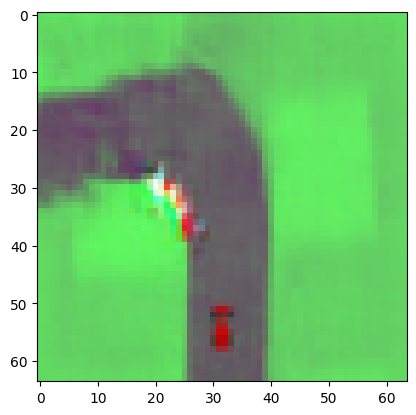

In [100]:
info = model.encode(x[0])
z = info["z"]
z = z.at[1].set(10.0)
# z = z.at[2].set(10.0)
# rngs = nnx.Rngs(19)
# rngs.normal((32))
plt.imshow(model.decode(z))

In [ ]:
from pathlib import Path

import orbax.checkpoint as ocp

In [109]:
def save_model(model: nnx.Module, model_name: str) -> None:
    _, state = nnx.split(model)
    checkpointer = ocp.StandardCheckpointer()
    ckpt_dir = Path("../checkpoints").resolve()
    fp = ckpt_dir / model_name
    checkpointer.save(fp, state, force=True)
    checkpointer.wait_until_finished()
    print(f"Saved model to {fp}")

In [110]:
save_model(model, "500k_example_vae")

Saved model to /Users/alexinch/noodling/world_models_paper/checkpoints/500k_example_vae
